- XGBoost model building, hyperparameter tuning and thershold tuning, everything is done in the previous notebook.

- It is continuation of that notebook where we are trying **Model Interpretability with SHAP**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('E:/Machine Learninng/Project/fraud-detection/data/creditcard.csv')

In [3]:
df = data.copy()

In [4]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [5]:
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00


In [6]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X['Time'] = scaler.fit_transform(X[['Time']])
# X['Amount'] = scaler.fit_transform(X[['Amount']])

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state = 2,test_size = 0.2,stratify=y)


In [8]:
# from sklearn.

In [34]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = np.sqrt(neg/pos)

print(scale_pos_weight)

24.026793419648342


In [35]:
from xgboost import XGBClassifier
xgb = XGBClassifier(colsample_bylevel= 0.8,
    learning_rate= 0.3,
    max_depth= 4,
    n_estimators= 200,
    subsample= 0.9,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [36]:
xgb.fit(X_train,y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,0.8
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
y_prob  =  xgb.predict_proba(X_test)[:,1]
y_pred  =  (y_prob>=0.22).astype(int)


Acuracy :  0.9995435553526912
Recall :  0.8571428571428571
Precision :  0.875
F1 Score :  0.865979381443299
ROC-AUC :  0.988264696002205
Average Precision :  0.8826911273497503


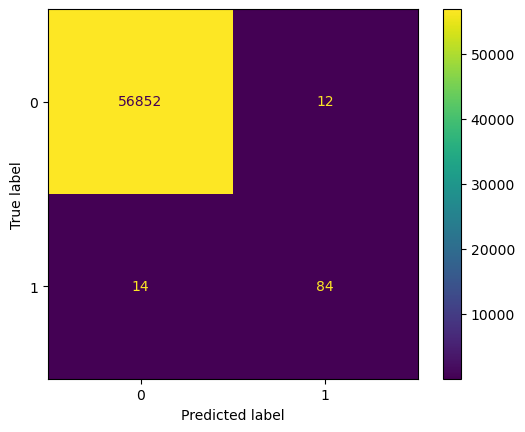

In [38]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,average_precision_score,confusion_matrix,ConfusionMatrixDisplay


print("Acuracy : ",accuracy_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("ROC-AUC : ",roc_auc_score(y_test,y_prob))
print("Average Precision : ",average_precision_score(y_test,y_prob))
obj = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred ))
obj.plot()

In [39]:
results = []
thresholds = np.linspace(0.1,0.9,81)
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.10,0.867347,0.867347,0.867347
1,0.11,0.876289,0.867347,0.871795
2,0.12,0.876289,0.867347,0.871795
3,0.13,0.876289,0.867347,0.871795
4,0.14,0.876289,0.867347,0.871795


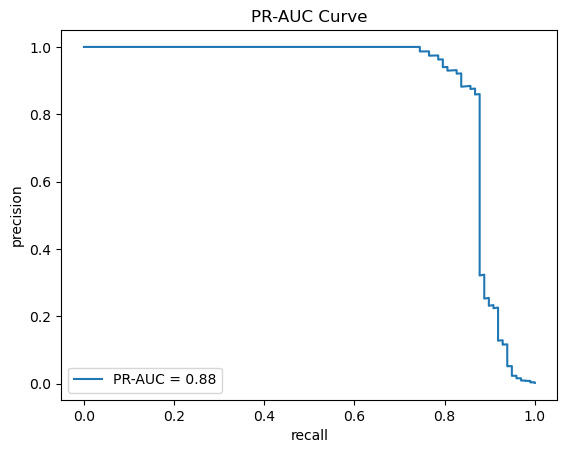

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix,confusion_matrix,precision_recall_curve,precision_score,average_precision_score,recall_score,f1_score,roc_auc_score,roc_curve

precision , recall,threshold = precision_recall_curve(y_test,y_prob)

avg_precision = average_precision_score(y_test,y_prob)

plt.plot(recall,precision,label=f"PR-AUC = {avg_precision:.2f}")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR-AUC Curve")
plt.legend()
plt.show()

In [41]:
import shap

In [42]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

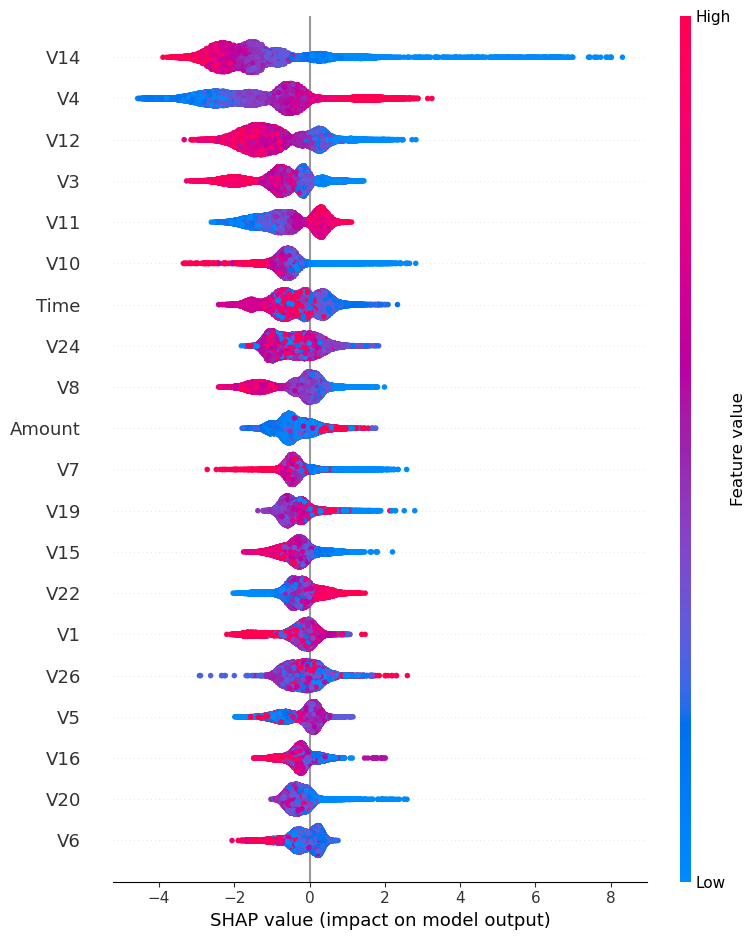

In [18]:
shap.summary_plot(shap_values,X_test)